# Collagen features — reducing the columns & finding what matters

You now have a table with **many columns** (35 measurements) but only a handful of
**rows** (one per core). That's a problem: with more columns than rows, patterns you
find can be flukes. This notebook does three things:

1. **Standardize** the columns so they're comparable.
2. **Find & drop redundant** measurements (many filters secretly measure the same thing).
3. Take a quick **unsupervised look** at whether the cores fall into groups.

> **Note:** this is only meaningful once you have *many* cores in the table (ideally all ~26).
> With 1–4 rows it just shows the machinery works.
>
> The next step after this — using **Lasso** to find which features predict patient
> outcome — needs survival data we don't have yet, so it's deliberately left for later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV

## 1. Load the feature table
This reads the CSV your first notebook made.

In [2]:
features = pd.read_csv("Features/collagen_features.csv", index_col="name")
print("Table shape:", features.shape, "(rows = cores, columns = measurements)")

if len(features) < 5:
    print("\n*** Only", len(features), "core(s) so far. The steps below will RUN, but")
    print("    the results aren't trustworthy until you have many cores. ***")
features.head()

Table shape: (4, 35) (rows = cores, columns = measurements)

*** Only 4 core(s) so far. The steps below will RUN, but
    the results aren't trustworthy until you have many cores. ***


,area_fraction,collagen_mean,collagen_median,collagen_sd,porosity,gabor_t0_f0.04_mean,gabor_t0_f0.04_var,gabor_t0_f0.08_mean,gabor_t0_f0.08_var,gabor_t0_f0.12_mean,...,gabor_t135_f0.08_mean,gabor_t135_f0.08_var,gabor_t135_f0.12_mean,gabor_t135_f0.12_var,meij_fiber_area,meij_skeleton_len,sato_fiber_area,sato_skeleton_len,alignment_coherence,dominant_orientation_rad
name,,,,,,,,,,,,,,,,,,,,,
In113_113In_Collagen (1),24.027708,1.469784,1.443635,0.635106,75.972292,0.166058,0.024712,0.078399,0.004064,0.051149,...,0.095566,0.006421,0.060648,0.002223,0.188505,52943,0.188244,57049,0.141384,-0.029000
In113_113In_Collagen copy 2,29.934236,1.352955,1.443635,0.523397,70.065764,0.161452,0.023821,0.090502,0.005682,0.062253,...,0.094976,0.006500,0.065745,0.002515,0.258903,90597,0.273300,116525,0.064437,-0.184042
In113_113In_Collagen copy 3,60.730000,1.509527,1.443635,0.548974,39.270000,0.126848,0.008630,0.086477,0.003189,0.068756,...,0.089011,0.003483,0.070098,0.001833,0.402404,176810,0.398680,238983,0.049349,0.002766
In113_113In_Collagen copy,9.043194,1.185431,0.881374,0.449485,90.956806,0.184435,0.054399,0.094718,0.013104,0.057777,...,0.081444,0.009091,0.047975,0.002592,0.070988,26698,0.083209,37663,0.060043,0.021740


## 2. Standardize (z-score) the columns
Right now the columns are on wildly different scales — `area_fraction` is ~24 while a
Gabor variance is ~0.006. If we don't fix that, the big-number columns drown out the
small ones. Z-scoring rewrites every column so it's centered at 0 with a spread of 1,
putting them all on equal footing.

In [3]:
X = features.values
X_scaled = StandardScaler().fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, index=features.index, columns=features.columns)
X_scaled.head()

,area_fraction,collagen_mean,collagen_median,collagen_sd,porosity,gabor_t0_f0.04_mean,gabor_t0_f0.04_var,gabor_t0_f0.08_mean,gabor_t0_f0.08_var,gabor_t0_f0.12_mean,...,gabor_t135_f0.08_mean,gabor_t135_f0.08_var,gabor_t135_f0.12_mean,gabor_t135_f0.12_var,meij_fiber_area,meij_skeleton_len,sato_fiber_area,sato_skeleton_len,alignment_coherence,dominant_orientation_rad
name,,,,,,,,,,,,,,,,,,,,,
In113_113In_Collagen (1),-0.367092,0.717586,0.577350,1.445555,0.367092,0.305410,-0.191633,-1.515680,-0.625448,-1.375482,...,0.933781,0.023710,-0.056447,-0.226770,-0.347565,-0.596103,-0.411781,-0.706502,1.712415,0.223606
In113_113In_Collagen copy 2,-0.053131,-0.210201,0.577350,-0.238904,0.053131,0.084223,-0.245384,0.494681,-0.211597,0.353285,...,0.830137,0.063549,0.558253,0.751417,0.239263,0.067597,0.323806,0.050532,-0.393109,-1.688219
In113_113In_Collagen copy 3,1.583816,1.033196,0.577350,0.146773,-1.583816,-1.577518,-1.161269,-0.173892,-0.849097,1.365732,...,-0.217421,-1.456356,1.083125,-1.536357,1.435471,1.587210,1.408120,1.609225,-0.805968,0.615323
In113_113In_Collagen copy,-1.163593,-1.540581,-1.732051,-1.353423,1.163593,1.187884,1.598286,1.194892,1.686142,-0.343534,...,-1.546497,1.369097,-1.584931,1.011709,-1.327168,-1.058704,-1.320145,-0.953255,-0.513338,0.849290


## 3. See which measurements are redundant
A correlation heatmap: each square shows how strongly two measurements move together.
Deep red = they rise and fall together (redundant — we only need one). Deep blue =
they move oppositely. Big red blocks mean lots of duplication we can safely trim.

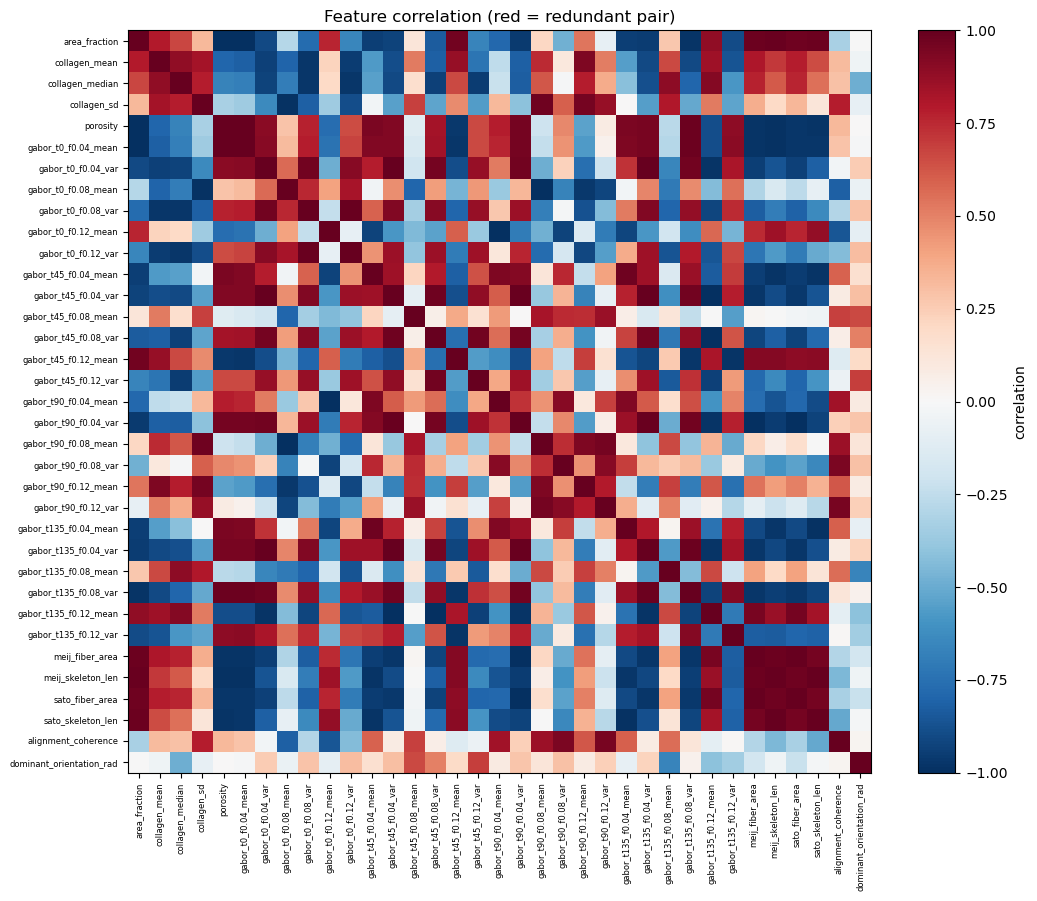

In [4]:
corr = X_scaled.corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=6)
fig.colorbar(im, label="correlation")
ax.set_title("Feature correlation (red = redundant pair)")
plt.tight_layout()

## 4. Drop the redundant ones (correlation pruning)
Simple rule: go through the measurements one by one; if a measurement is almost a copy
of one we've already kept (correlation above 0.95), drop it. This keeps a smaller,
non-duplicated set — and unlike PCA, every kept column still has its original meaning,
so you can still say *which* feature mattered. That interpretability is why your mentor
prefers this direction.

In [5]:
def prune_correlated(df, threshold=0.95):
    keep, drop = [], []
    corr = df.corr().abs()
    for col in df.columns:
        # is this column nearly a duplicate of something we already kept?
        if any(corr.loc[col, k] > threshold for k in keep):
            drop.append(col)
        else:
            keep.append(col)
    return keep, drop

kept, dropped = prune_correlated(X_scaled, threshold=0.95)
print(f"Kept {len(kept)} features, dropped {len(dropped)} redundant ones.\n")
print("KEPT:", kept)
print("\nDROPPED (redundant):", dropped)

X_reduced = X_scaled[kept]

Kept 15 features, dropped 20 redundant ones.

KEPT: ['area_fraction', 'collagen_mean', 'collagen_median', 'collagen_sd', 'gabor_t0_f0.04_var', 'gabor_t0_f0.12_mean', 'gabor_t45_f0.04_mean', 'gabor_t45_f0.08_mean', 'gabor_t45_f0.12_var', 'gabor_t90_f0.08_var', 'gabor_t90_f0.12_var', 'gabor_t135_f0.08_mean', 'gabor_t135_f0.12_var', 'alignment_coherence', 'dominant_orientation_rad']

DROPPED (redundant): ['porosity', 'gabor_t0_f0.04_mean', 'gabor_t0_f0.08_mean', 'gabor_t0_f0.08_var', 'gabor_t0_f0.12_var', 'gabor_t45_f0.04_var', 'gabor_t45_f0.08_var', 'gabor_t45_f0.12_mean', 'gabor_t90_f0.04_mean', 'gabor_t90_f0.04_var', 'gabor_t90_f0.08_mean', 'gabor_t90_f0.12_mean', 'gabor_t135_f0.04_mean', 'gabor_t135_f0.04_var', 'gabor_t135_f0.08_var', 'gabor_t135_f0.12_mean', 'meij_fiber_area', 'meij_skeleton_len', 'sato_fiber_area', 'sato_skeleton_len']


## 5. Quick unsupervised look: do the cores separate?
Before any prediction, it's useful to just *eyeball* whether the cores fall into groups.
We squash the many columns down to 2 so we can plot each core as a dot.

> We use PCA **only for this 2-D picture**, not as input to the final model — your mentor's
> hesitation about PCA is about using its components as model features, which we're not doing.
> (`umap-learn` is a nice nonlinear alternative for this plot if you install it later.)

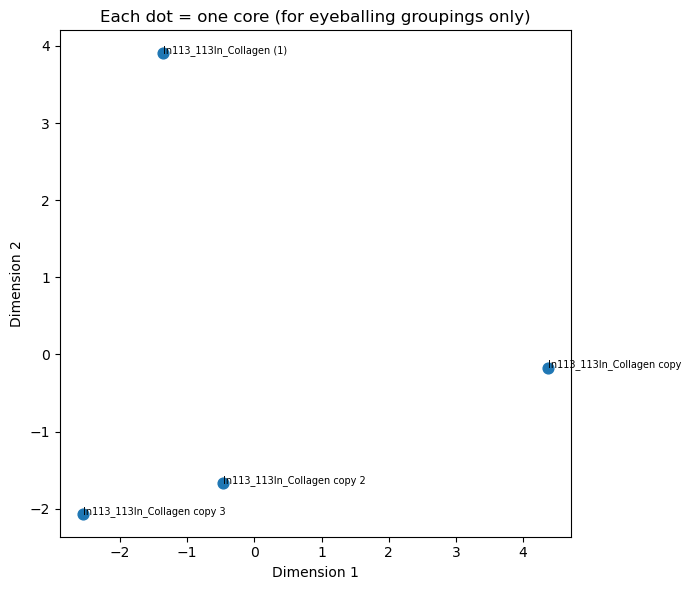

In [6]:
if len(features) >= 3:
    coords = PCA(n_components=2).fit_transform(X_reduced.values)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(coords[:, 0], coords[:, 1], s=60)
    for i, name in enumerate(X_reduced.index):
        ax.annotate(str(name), (coords[i, 0], coords[i, 1]), fontsize=7)
    ax.set_xlabel("Dimension 1"); ax.set_ylabel("Dimension 2")
    ax.set_title("Each dot = one core (for eyeballing groupings only)")
    plt.tight_layout()
else:
    print("Need at least 3 cores to make this plot.")

## What comes next (not yet)
Once you have **all ~26 cores** in the table AND **patient outcome data**, the next step is
**Lasso** — a method that keeps only the handful of features that actually predict outcome.
We're holding off on that until the outcome data exists.